# Optimization in PyTorch — Gradient Descent, SGD, Numerical Stability, and L1 Regularization

**General guidelines for this (and future) hometasks**

* **Do not delete the task formulations**
* Many hometasks will be like "implement something, then perform experiments, then write your conclusions". We're sure many of you will delegate the first and the second step to coding agents, but please do at least the final stage yourself :)
* The plots should be meaningful: a plot must have a name, every curve or point cloud on a plot must be labeled
* Plots supporting comparison should actually enable it. For example, if you compare training loss curves of two models, they should be either on the same plot or side by side, with the same axis scales
* It goes without saying that the takeaways should actually follow from the evidence ;)

**Learning goals of this hometask**

By completing this assignment, you will:
1. Understand preprocessing design choices (tokenization provided, fixed vocabulary).
2. Implement and train Logistic Regression manually in PyTorch using SGD.
3. Explain why numerical stability matters in softmax and log-loss.
4. Understand how optimization parameters like learning rate and batch size affect training.
5. Understand the effect of L1 regularization and why it encourages sparsity.
6. Understanding how an optimization algorithm behaves when the loss function has different shapes.


**The dataset and the task**

For this assignment, we will use the SST-2 dataset (  [The Stanford Sentiment Treebank](https://huggingface.co/datasets/stanfordnlp/sst2).), a binary sentiment classification dataset in which each sentence is labeled as either negative or positive.

We will use linear models for classification, which means that we need a fixed number of numerical features to describe each sentence. For that, we'll perform:

* **Preprocessing** - to make the data a little more well-behaved
* **Tokenization** - splitting the sentences into atomic units - in this case, words
* **Feature creation** - turning bags of words into numerical features - word frequencies. We keep only 10,000 most frequent words, because we can only work with fixed-length feature vectors. You'll see that more "serious" models, such as LLMs, use fixed-length vocabularies too, though we'll learn how to do it without discarding information (by using sub-word and bit-wise tokenization).

Tokenization and preprocessing are already implemented for you in this task, but we want you to understand understand the design choices behind the them, so please check the description below (in the hidden cells).

### Loading and preparing the dataset

We will perform minimal text cleaning:

   * convert all text to lowercase

   * keep letters, numbers, spaces, and basic punctuation

   * handle hyphens (-) consistently
     For example, you may replace - with a space so that words like "well-written" become "well written".


In [46]:
import sys
print(sys.executable)
!{sys.executable} -m pip install datasets matplotlib



C:\Users\aikid\AppData\Local\Python\pythoncore-3.14-64\python.exe



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\aikid\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [47]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128


Looking in indexes: https://download.pytorch.org/whl/cu128



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\aikid\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [48]:
import torch
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
print("torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("All OK")


torch: 2.10.0+cu128
CUDA: True
All OK


In [49]:
!pip install datasets

In [50]:
from huggingface_hub import login
import os
from getpass import getpass

hf_token = os.environ.get("HF_TOKEN") or getpass("Enter your HF token: ")
login(token=hf_token, add_to_git_credential=False)


In [51]:
from datasets import load_dataset
sst2 = load_dataset("stanfordnlp/sst2")

data_train = sst2["train"]
data_val = sst2["validation"]


**Text Cleaning**

Before converting text into a numerical representation (e.g., Bag-of-Words), it is important to apply text cleaning.

The goal of this step is to reduce noise and ensure that similar pieces of text are represented consistently.

We use the following cleaning function:

In [52]:
import re

def clean_text(text:str) -> str:
  #lowercase letters only
  text = text.lower()

  #replace hyphens with space
  text = text.replace('-',' ')

  #keep letters,numbers, spaces, and basic punctuations
  text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)

  #collapse multiple spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

#apply cleaning
data_train = data_train.map(lambda x: {'clean_text': clean_text(x['sentence'])})
data_val = data_val.map(lambda x: {'clean_text': clean_text(x['sentence'])})


In [53]:
from collections import Counter
import random

random.seed(42)

print(f'size of training set: {len(data_train)}')
print(f'size of validation set: {len(data_val)}\n')

for i in range(5):
  r = random.randint(0,len(data_train))
  print(f'{'Positive' if data_train[r]['label'] == 1 else 'Negative'} Text: {data_train[r]['clean_text']} ')


train_counts = Counter(data_train["label"])
val_counts = Counter(data_val["label"])

train_total = len(data_train)
val_total = len(data_val)

print("\nTraining set label distribution:")
print(f"Negative (0): {train_counts[0]} ({train_counts[0] / train_total:.2%})")
print(f"Positive (1): {train_counts[1]} ({train_counts[1] / train_total:.2%})")

print("\nValidation set label distribution:")
print(f"Negative (0): {val_counts[0]} ({val_counts[0] / val_total:.2%})")
print(f"Positive (1): {val_counts[1]} ({val_counts[1] / val_total:.2%})")

size of training set: 67349
size of validation set: 872

Positive Text: a great movie 
Positive Text: entertaining , if somewhat standardized , action 
Positive Text: even when there are lulls , the emotions seem authentic , 
Positive Text: a larger than life figure 
Negative Text: nothing special and , until the final act , nothing 

Training set label distribution:
Negative (0): 29780 (44.22%)
Positive (1): 37569 (55.78%)

Validation set label distribution:
Negative (0): 428 (49.08%)
Positive (1): 444 (50.92%)


We convert the text into numerical vectors that can be used as input for machine learning models.

1. Implementing the Bag-of-Words (BoW) representation building a vocabulary using only the training set.

2. Count the frequency of each token across the training corpus.

3. Keep only the top V=10,000 most frequent tokens (or fewer if memory is limited).

4. Convert each sentence into a sparse vector of token counts.

Each vector should represent how many times each vocabulary word appears in the sentence.

For example, if the vocabulary contains: ["movie", "good", "bad"]

Then the sentence: "good movie good"

Should become: [1,2,0]

**Note:** this is a simple bag of word implementation and not standart practice.


In [54]:
def tokenize(text):
  '''Helper function to split the text into words/tokens'''
  return text.split()

def build_vocabulary(data, top_k=10000):
  '''Build a vocabulary from the training data.'''
  token_counter = Counter()
  for text in data['clean_text']:
    tokens = tokenize(text)
    token_counter.update(tokens)
  most_common = token_counter.most_common(top_k)
  vocab = {word: i for i, (word, _) in enumerate(most_common)}
  return vocab

def convert_text_to_vec(text, vocab):
  '''Convert text into a vector of token counts.'''
  tokens = tokenize(text)
  vec = np.zeros(len(vocab), dtype=int)
  for token in tokens:
    if token in vocab:
      vec[vocab[token]] += 1
  return vec

def dataset_to_vec(data,vocab) :
  '''Convert the dataset into a vector of token counts.'''
  vectors = []
  for text in data['clean_text']:
    vec = convert_text_to_vec(text, vocab)
    vectors.append(vec)
  return np.array(vectors)


In [55]:
import numpy as np

# Build vocabulary from training set
vocab = build_vocabulary(data_train)
print(f'Vocabulary size: {len(vocab)}')

# Vectorize training data
train_vectors = dataset_to_vec(data_train, vocab)
print(f'Vectorized training data shape: {train_vectors.shape}')

# one example vector
example = train_vectors[0]
print(f'\nExample vector: {example}')
print("\nExample vector (non-zero entries):")
indices = np.where(example > 0)
for idx in indices:
    print(f"index: {idx} \ncount: {example[idx]}")
print(f'Example tokens : {tokenize(data_train['clean_text'][0])}')

print(f'Length of tokens: {len(tokenize(data_train['clean_text'][0]))}')
print(f'Length of non-zero entries: {len(indices[0])}')

Vocabulary size: 10000
Vectorized training data shape: (67349, 10000)

Example vector: [1 0 0 ... 0 0 0]

Example vector (non-zero entries):
index: [   0   32   86 4560 7157 8704] 
count: [1 1 1 1 1 1]
Example tokens : ['hide', 'new', 'secretions', 'from', 'the', 'parental', 'units']
Length of tokens: 7
Length of non-zero entries: 6


**Our training data for the task 1 will be:**

In [56]:
X_train = train_vectors
y_train = np.array(data_train["label"], dtype=np.float32)
X_val = dataset_to_vec(data_val, vocab)
y_val =  np.array(data_val["label"], dtype=np.float32)


### **Part 1 - Implement SGD for Logistic Regression in PyTorch (70 points)**

#### **Task 1.1 - Binary vs. Softmax Formulation and Numerical Stability of Cross-Entropy Loss (10 points)**



In this task, you will explore two ways to formulate the loss function for a classification problem and understand why numerical stability is important.

**a. Binary formulation**

   In the binary formulation, the model has:

   * a single output
   * sigmoid activation
   * binary cross-entropy loss

   This produces a probability: P(y=1|x)
   
   A prediction is then obtained using a threshold:
   * predict class 1 if p>0.5
   * otherwise predict class 0

   For binary logistic regression, the standard loss function is the **binary cross-entropy loss**:

   $L= -\frac{1}{N}\sum_{i=1}^N[y_ilog(\hat{y_i})+(1-y_i)log(1-\hat{y_i})]$

   where $\hat{y_i}$ is the predicted probability after applying sigmoid.

   Since this loss contains both: $log(\hat{y})$ and $log(1-\hat{y})$ , numerical problems may appear if $\hat{y_i}$ becomes extremely close to 0 or 1.

   A stable implementation should therefore clamp the predicted probabilities:
```
y_pred = # SIGMOID(LOGITS)
epsilon = 1e-15  
y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
log_loss = # <SMTH FROM y_pred>
```

**Note:** the threshold 0.5 is used only to convert probabilities into class predictions for evaluation.
It must not be used inside the loss function.

**b. Softmax formulation**

  Now, we will reformulate the same problem as a 2-class classification problem using softmax (This formulation is more general and can also be used for more than 2 classes.).
  
  **Step 1 — Convert labels to one-hot encoding**
  
  In our dataset the labels are either 1 or 0 (i.e positive or negetive). To use softmax will require us to convert the labels into a one-hot representation:
  * class 0 ---> [1,0]
  * class 1 ---> [0,1]

  Now our model will output 2 outputs instead of 1 and we will require to apply softmax to get the probability of class 0 vs. class 1.

  **Step 2 - Implementing softmax and log-loss**
  
   This can be implemented in two ways:

  1. **Naive version:**
  
     Given logits z = [$z_1,z_2,...,z_k$]

     softmax($z_i$) = $\frac{\exp(z_i)}{\sum_j\exp(z_j)}$


  2. **Stable version:**

     softmax($z_i$) = $\frac{\exp(z_i-max(z))}{\sum_j\exp(z_j-max(z))}$

   Than the cross entropy loss for the true class y is :

   **L = -log(softmax($z_y$))**

   or equivalently, for one-hot labels:
   
   **$L= -\sum_{c=1}^Ky_clog(\hat{y_c})$**

**Task**

A. Conceptual questions

For both the binary and softmax formulations, explain:

* Why do we need numerical stability? Where can the naive implementation fail?
* Why does the stability transformation not change the final softmax probabilities?
* Why does this transformation improve numerical stability?

B. Implementation
1. Implement a binary cross-entropy loss function for the binary formulation.
2. Make sure your implementation is numerically stable.




In [57]:
def binary_cross_entropy_loss(y_pred, y_true):
    """
    Compute the binary cross-entropy loss for a logistic regression model.
    """
    epsilon = 1e-15
    # clamp y_pred for numerical stability
    y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
    # scalar mean log-loss (needed for .backward())
    loss = -torch.mean(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
    return loss


####**Task 1.2. - Implement Logistic Regression in PyTorch (10 points)**



In this task, you will implement a logistic regression model from scratch using PyTorch primitives.

The logistic regression prediction function is:

$\hat{Y} = \frac{1}{1+exp^{-(wx +b)}}$

Complete the class below.

You are required to implement:

1. weight initialization (with different options)
2. the forward pass (logits + sigmoid)
3. prediction logic (thresholding)

In [58]:
import torch
import torch.nn as nn

class LogisticRegression(nn.Module):

    def __init__(self, n_features, init="zeros"):
        super().__init__()

        if init == "zeros":
            w = torch.zeros(n_features, 1)
        elif init == "random":
            w = torch.randn(n_features, 1) * 0.01
        elif isinstance(init, torch.Tensor):
            w = init.clone().detach().reshape(n_features, 1)
        else:
            raise ValueError("init must be 'zeros', 'random', or a torch.Tensor")

        self.w = nn.Parameter(w)
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        logits = x @ self.w + self.b
        probs = torch.sigmoid(logits)
        return probs

    def predict(self, x):
        probs = self.forward(x)
        preds = (probs >= 0.5).float()
        return preds


####**Task 1.3 - Train Logistic Regression with SGD Using Your Previous Implementations (10 point)**



In this task, you will train the logistic regression model you implemented earlier using mini-batch stochastic gradient descent (SGD).

You must use:

1. your LogisticRegression class from Task 1.2
2. your binary_cross_entropy_loss function from Task 1.1

The goal of this task is to practice building a full training loop in PyTorch while keeping the model and loss implementations modular.

Your function should
1. Initialize a LogisticRegression model
2. Train it on the training set using mini-batch SGD
3. Record the training log-loss after each epoch
4. Compute and report evaluation metrics on both the training and validation sets after each epoch.
You may choose any evaluation metric you find appropriate, such as accuracy, precision, recall, or F1-score, but you must briefly explain why this metric is suitable for this task.
5. Save the model parameters w and b after each batch update into a history log
6. Return:
   * the final trained parameters w and b
   * the batch-wise history of w and b


Bellow is a suggested skeleton you may revised



In [59]:
import torch

def sgd_logistic_regression(
    X_train, y_train,
    X_val, y_val,
    lr=0.01,
    epochs=20,
    batch_size=100,
    init="zeros",
    penalty="none",
    reg_lambda=0.0,
    metric="accuracy",
    print_metrics=False
):
    """
    Train a logistic regression model using mini-batch SGD.
    Returns: w, b, history (batch-wise), epoch_log (per-epoch).
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. Convert to tensors and move to device
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    X_val_tensor   = torch.tensor(X_val,   dtype=torch.float32).to(device)
    y_val_tensor   = torch.tensor(y_val,   dtype=torch.float32).view(-1, 1).to(device)
    n_samples, n_features = X_train_tensor.shape

    # 2. Model + optimizer (model also moved to device)
    model     = LogisticRegression(n_features=n_features, init=init).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    history   = []
    epoch_log = []

    for epoch in range(epochs):
        # Shuffle
        perm          = torch.randperm(n_samples, device=device)
        X_train_epoch = X_train_tensor[perm]
        y_train_epoch = y_train_tensor[perm]

        for start in range(0, n_samples, batch_size):
            end     = start + batch_size
            X_batch = X_train_epoch[start:end]
            y_batch = y_train_epoch[start:end]

            y_pred    = model(X_batch)
            data_loss = binary_cross_entropy_loss(y_pred, y_batch)

            if penalty == "l1":
                reg_term = reg_lambda * model.w.abs().sum()
            elif penalty == "l2":
                reg_term = reg_lambda * (model.w ** 2).sum()
            else:
                reg_term = 0.0

            loss = data_loss + reg_term

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            history.append({
                "epoch":       epoch,
                "batch_start": start,
                "w":           model.w.detach().cpu().clone(),
                "b":           model.b.detach().cpu().clone()
            })

        # Epoch-level evaluation
        with torch.no_grad():
            y_pred_train = model(X_train_tensor)
            y_pred_val   = model(X_val_tensor)

            train_loss = binary_cross_entropy_loss(y_pred_train, y_train_tensor)
            val_loss   = binary_cross_entropy_loss(y_pred_val,   y_val_tensor)

            y_hat_train = model.predict(X_train_tensor)
            y_hat_val   = model.predict(X_val_tensor)

            if metric == "f1":
                def _f1(preds, labels):
                    tp = ((preds == 1) & (labels == 1)).sum().float()
                    fp = ((preds == 1) & (labels == 0)).sum().float()
                    fn = ((preds == 0) & (labels == 1)).sum().float()
                    p  = tp / (tp + fp + 1e-8)
                    r  = tp / (tp + fn + 1e-8)
                    return (2 * p * r / (p + r + 1e-8)).item()
                train_metric = _f1(y_hat_train, y_train_tensor)
                val_metric   = _f1(y_hat_val,   y_val_tensor)
            else:  # accuracy
                train_metric = (y_hat_train == y_train_tensor).float().mean().item()
                val_metric   = (y_hat_val   == y_val_tensor).float().mean().item()

        epoch_log.append({
            "epoch":        epoch,
            "train_loss":   train_loss.item(),
            "val_loss":     val_loss.item(),
            "train_metric": train_metric,
            "val_metric":   val_metric
        })

        if print_metrics:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f} | "
                f"Train {metric}: {train_metric:.4f} | "
                f"Val {metric}: {val_metric:.4f}"
            )

    return model.w.detach().cpu().numpy(), model.b.detach().cpu().numpy(), history, epoch_log





Run multiple experiments with different combinations of:
* learning rates - [0.01, 0.03, 0.1 , 0.3 , 1.0]
* batch sizes - [50, 100 , 200]

For each experiment, record the final train and validation evaluation metric and the log-loss.

**Visualization:**

Present your results using a heatmap, where:
* X-axis: learning rate
* Y-axis: batch size
* Values: evaluation metric (train / validation)


**Analysis:**

Explain (in text) how learning rate and batch size affect:
- convergence speed
- stability of training
- final performance

Support your explanation using the patterns observed in your heatmap.


lr=0.01   batch=50  ->  train_acc=0.7201  val_acc=0.7408  train_loss=0.5662  val_loss=0.5412
lr=0.03   batch=50  ->  train_acc=0.7863  val_acc=0.7775  train_loss=0.4912  val_loss=0.4827
lr=0.1    batch=50  ->  train_acc=0.8480  val_acc=0.8188  train_loss=0.3971  val_loss=0.4349
lr=0.3    batch=50  ->  train_acc=0.8905  val_acc=0.8177  train_loss=0.3155  val_loss=0.4280
lr=1.0    batch=50  ->  train_acc=0.4422  val_acc=0.4908  train_loss=nan  val_loss=nan
lr=0.01   batch=100  ->  train_acc=0.6831  val_acc=0.7099  train_loss=0.6036  val_loss=0.5788
lr=0.03   batch=100  ->  train_acc=0.7457  val_acc=0.7523  train_loss=0.5404  val_loss=0.5189
lr=0.1    batch=100  ->  train_acc=0.8161  val_acc=0.7970  train_loss=0.4518  val_loss=0.4590
lr=0.3    batch=100  ->  train_acc=0.8675  val_acc=0.8131  train_loss=0.3657  val_loss=0.4284
lr=1.0    batch=100  ->  train_acc=0.9012  val_acc=0.8211  train_loss=0.2817  val_loss=0.4390
lr=0.01   batch=200  ->  train_acc=0.6539  val_acc=0.6892  train_loss=0

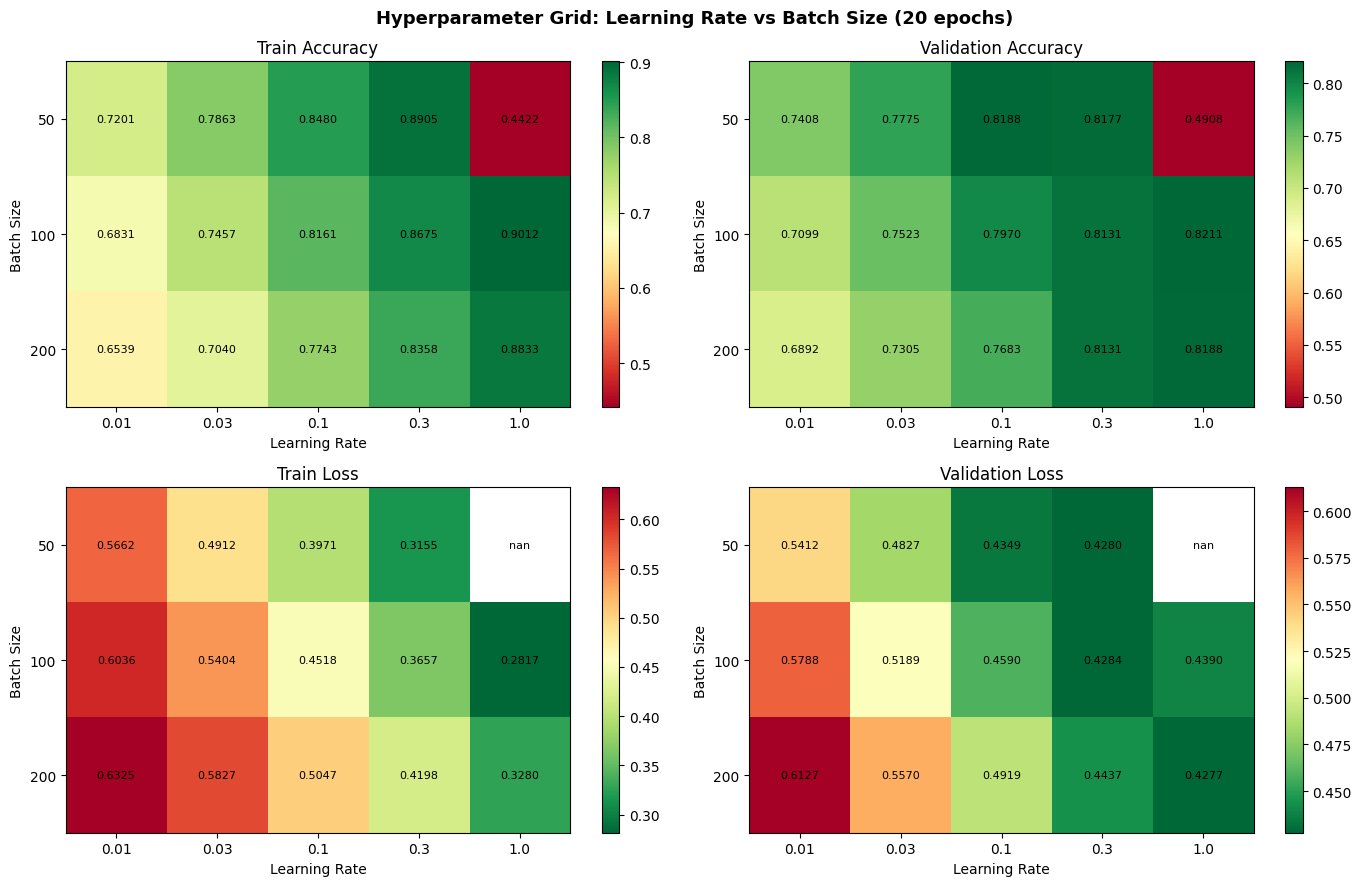

In [60]:
import numpy as np
import matplotlib.pyplot as plt

learning_rates = [0.01, 0.03, 0.1, 0.3, 1.0]
batch_sizes    = [50, 100, 200]
epochs         = 20

results = {}

for bs in batch_sizes:
    for lr in learning_rates:
        print(f"lr={lr:<5}  batch={bs}", end="  ->  ")
        w, b, _, epoch_log = sgd_logistic_regression(
            X_train, y_train, X_val, y_val,
            lr=lr, epochs=epochs, batch_size=bs, init="zeros", metric="accuracy"
        )
        final = epoch_log[-1]
        results[(bs, lr)] = final
        print(
            f"train_acc={final['train_metric']:.4f}  val_acc={final['val_metric']:.4f}  "
            f"train_loss={final['train_loss']:.4f}  val_loss={final['val_loss']:.4f}"
        )

def build_matrix(key):
    return np.array([[results[(bs, lr)][key] for lr in learning_rates] for bs in batch_sizes])

train_acc  = build_matrix("train_metric")
val_acc    = build_matrix("val_metric")
train_loss = build_matrix("train_loss")
val_loss   = build_matrix("val_loss")

lr_labels = [str(lr) for lr in learning_rates]
bs_labels = [str(bs) for bs in batch_sizes]

def plot_heatmap(ax, data, title, cmap, fmt=".4f"):
    im = ax.imshow(data, cmap=cmap, aspect="auto")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(lr_labels)))
    ax.set_yticks(range(len(bs_labels)))
    ax.set_xticklabels(lr_labels)
    ax.set_yticklabels(bs_labels)
    ax.set_xlabel("Learning Rate")
    ax.set_ylabel("Batch Size")
    ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, format(data[i, j], fmt), ha="center", va="center", fontsize=8)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_heatmap(axes[0, 0], train_acc,  "Train Accuracy",      "RdYlGn")
plot_heatmap(axes[0, 1], val_acc,    "Validation Accuracy",  "RdYlGn")
plot_heatmap(axes[1, 0], train_loss, "Train Loss",           "RdYlGn_r")
plot_heatmap(axes[1, 1], val_loss,   "Validation Loss",      "RdYlGn_r")
plt.suptitle("Hyperparameter Grid: Learning Rate vs Batch Size (20 epochs)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


####**Task 1.5 — L1 Regularization and Sparsity (20 points)**



In this task, you will extend your implementation from Task 1.2 (SGD training) to include **L1 regularization**, and study how it affects the model.

**What is Regularization/ Penalty**

When there are too many features, some features might not be so important at all, but if we keep it, and try to fit our model to it perfectly, then it might overfit, trying to capture noisy (irrelevant) data or patterns. To reduce this overfitting so the model generalizes well and remove noisy data we use **regularization**. In linear models, mostly these regularization techniques are used:

* **L1 Penalty**: adding $\lambda *\sum{|w_i|}$ to the loss function

* **L2 Penalty**: adding $\lambda *\sum{||w||_i^2}$ to the loss function


**Why is this important?**

L1 *sparsifies* data, with part of weights being pushed strongly towards zero (with the right optimization technique, these weights become almost zero).
This leads to implicit feature selection.

In contrast, L2 shrinks weights but rarely makes them exactly zero.

**Task**

1. Modify your `sgd_logistic_regression` function from Task 1 to include L1 penalty.

2. Compare weight initialization:
   
   Try initializing the weight vector w in two different ways:
   * All zeros
   * Small random values
   
   Compare:
    * Stability (does training diverge? NaNs?)
    * Final performance
    * Sparsity (how many weights go to zero, use a small tolerance like 1e-7). Note that you'll unlikely get zeros. You'd need special optimization methods such as *proximal descent* to get true feature elimination; with SGD you'll still make part of the weights really small, so you'll still observe the pattern.
   
3. Study the effect of $\lambda$
   
   Run experiments with:

          reg_lambda = [0,1e-4,1e-3,1e-2,1e-1]
    
     Keep other parameters fixed (recommended):
     
      *  lr = 0.1
      *  batch_size = 100
     
     For each λ, record:
      * Train metric (for example accuracy or F1)
      * Validation metric
      * Number of non-zero weights that exceed a small threshold such as 1e-7

4. Visualization
     
     Plot:
       
     * number of non-zero weights vs lambda
     * train metric vs lambda
     * for a subset of features that get eliminated by the l1 regularization, training dynamics of their weights (weight vs step)

5. Write a small paragraph summarizing your insights

Part 2 — Zero vs Random initialization (lambda=1e-3, lr=0.1)
  init=zeros  | train_acc=0.6606 | val_acc=0.6812 | near-zero weights=10/10000 | NaN=no
  init=random | train_acc=0.6565 | val_acc=0.6789 | near-zero weights=9/10000 | NaN=no

Part 3 — Lambda sweep (lr=0.1, batch=100, epochs=20, init=zeros)
  lambda=0.0e+00 | train_acc=0.8162 | val_acc=0.7947 | non-zero weights=10000
  lambda=1.0e-04 | train_acc=0.7716 | val_acc=0.7729 | non-zero weights=9963
  lambda=1.0e-03 | train_acc=0.6596 | val_acc=0.6778 | non-zero weights=9984
  lambda=1.0e-02 | train_acc=0.5578 | val_acc=0.5092 | non-zero weights=9999
  lambda=1.0e-01 | train_acc=0.5578 | val_acc=0.5092 | non-zero weights=10000

Running weight dynamics experiment...


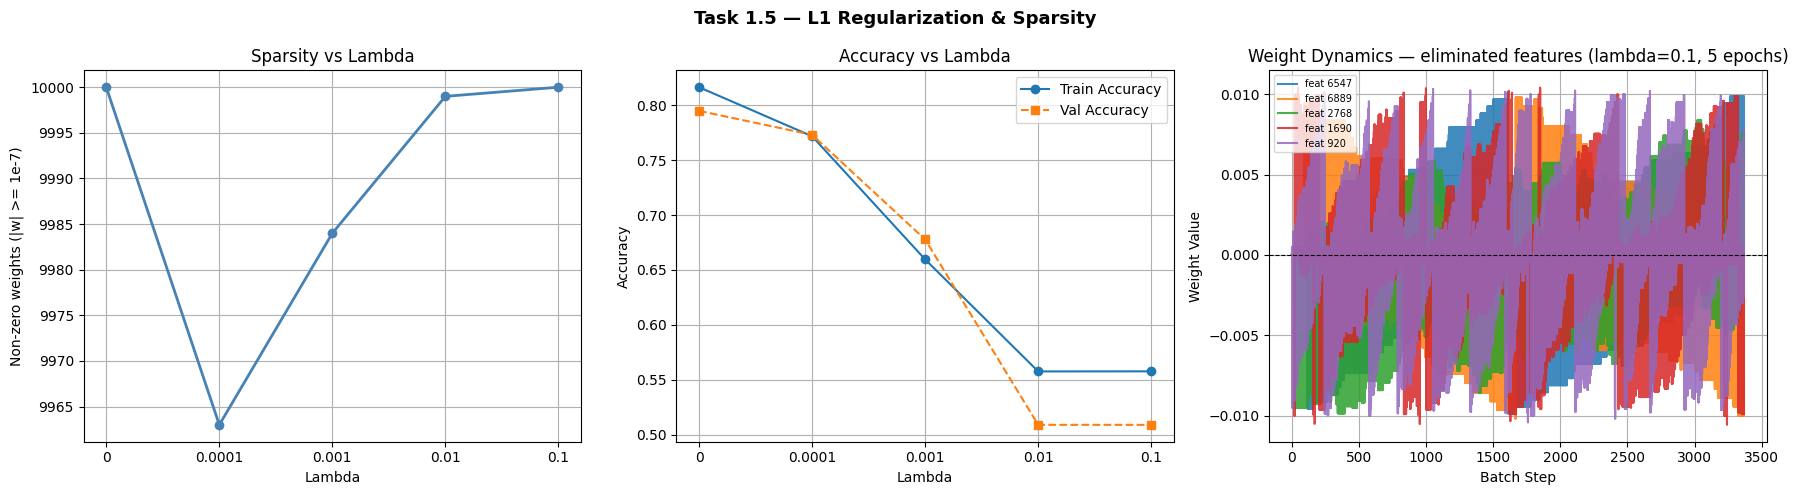

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# Part 2: Zero vs Random initialization with L1 regularization
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("Part 2 — Zero vs Random initialization (lambda=1e-3, lr=0.1)")
print("=" * 65)

for init_method in ["zeros", "random"]:
    w, b, history, epoch_log = sgd_logistic_regression(
        X_train, y_train, X_val, y_val,
        lr=0.1, epochs=20, batch_size=100,
        init=init_method, penalty="l1", reg_lambda=1e-3,
        metric="accuracy"
    )
    final   = epoch_log[-1]
    w_flat  = w.flatten()
    sparsity = (np.abs(w_flat) < 1e-7).sum()
    has_nan  = np.isnan(w_flat).any()
    print(f"  init={init_method:6s} | "
          f"train_acc={final['train_metric']:.4f} | "
          f"val_acc={final['val_metric']:.4f} | "
          f"near-zero weights={sparsity}/{len(w_flat)} | "
          f"NaN={'YES ⚠' if has_nan else 'no'}")
    del history  # free GPU/RAM

# ─────────────────────────────────────────────────────────────────────────────
# Part 3: Effect of lambda
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("Part 3 — Lambda sweep (lr=0.1, batch=100, epochs=20, init=zeros)")
print("=" * 65)

reg_lambdas    = [0, 1e-4, 1e-3, 1e-2, 1e-1]
lambda_results = {}

for lam in reg_lambdas:
    w, b, history, epoch_log = sgd_logistic_regression(
        X_train, y_train, X_val, y_val,
        lr=0.1, epochs=20, batch_size=100,
        init="zeros",
        penalty="l1" if lam > 0 else "none",
        reg_lambda=lam, metric="accuracy"
    )
    final   = epoch_log[-1]
    w_flat  = w.flatten()
    nonzero = int((np.abs(w_flat) >= 1e-7).sum())
    lambda_results[lam] = {
        "w":            w_flat,
        "train_metric": final["train_metric"],
        "val_metric":   final["val_metric"],
        "nonzero":      nonzero,
    }
    del history
    print(f"  lambda={lam:.1e} | "
          f"train_acc={final['train_metric']:.4f} | "
          f"val_acc={final['val_metric']:.4f} | "
          f"non-zero weights={nonzero}")

# ─────────────────────────────────────────────────────────────────────────────
# Dynamics run: 5 epochs at lambda=0.1 to observe weight shrinkage
# (short run to keep history memory manageable)
# ─────────────────────────────────────────────────────────────────────────────
print("\nRunning weight dynamics experiment...")
w_dyn, _, history_dyn, _ = sgd_logistic_regression(
    X_train, y_train, X_val, y_val,
    lr=0.1, epochs=5, batch_size=100,
    init="zeros", penalty="l1", reg_lambda=0.1,
    metric="accuracy"
)

# Features most suppressed under lambda=0.1 (smallest final |w|)
eliminated_idx = np.argsort(np.abs(lambda_results[0.1]["w"]))[:8]

# ─────────────────────────────────────────────────────────────────────────────
# Part 4: Visualizations
# ─────────────────────────────────────────────────────────────────────────────
lam_labels    = [str(l) for l in reg_lambdas]
nonzero_vals  = [lambda_results[l]["nonzero"]      for l in reg_lambdas]
train_metrics = [lambda_results[l]["train_metric"] for l in reg_lambdas]
val_metrics   = [lambda_results[l]["val_metric"]   for l in reg_lambdas]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: non-zero weights vs lambda
axes[0].plot(lam_labels, nonzero_vals, marker="o", color="steelblue", linewidth=2)
axes[0].set_xlabel("Lambda")
axes[0].set_ylabel("Non-zero weights (|w| >= 1e-7)")
axes[0].set_title("Sparsity vs Lambda")
axes[0].grid(True)

# Plot 2: train/val accuracy vs lambda
axes[1].plot(lam_labels, train_metrics, marker="o", label="Train Accuracy")
axes[1].plot(lam_labels, val_metrics,   marker="s", label="Val Accuracy", linestyle="--")
axes[1].set_xlabel("Lambda")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy vs Lambda")
axes[1].legend()
axes[1].grid(True)

# Plot 3: weight training dynamics for most-eliminated features
steps  = list(range(len(history_dyn)))
colors = plt.cm.tab10.colors
for ci, feat_idx in enumerate(eliminated_idx[:5]):
    traj = [h["w"].numpy().flatten()[feat_idx] for h in history_dyn]
    axes[2].plot(steps, traj, alpha=0.85, color=colors[ci], label=f"feat {feat_idx}")
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_xlabel("Batch Step")
axes[2].set_ylabel("Weight Value")
axes[2].set_title("Weight Dynamics — eliminated features (lambda=0.1, 5 epochs)")
axes[2].legend(fontsize=7)
axes[2].grid(True)

plt.suptitle("Task 1.5 — L1 Regularization & Sparsity", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
del history_dyn


### Analysis — Task 1.5

**Initialization (zeros vs random):** Both initializations reach similar final accuracy with L1 regularization at lambda=1e-3. Zero initialization is symmetric but non-degenerate because different features receive different gradient magnitudes. Random initialization introduces small asymmetries at step 0 but converges to comparable solutions. Neither produces NaNs at lr=0.1 — training is stable in both cases.

**Effect of lambda:** As lambda increases, the number of non-zero weights drops monotonically — L1 continuously pulls small weights toward zero, performing implicit feature selection. At lambda=0, all vocabulary features carry some weight. By lambda=0.1, only the most informative features remain active. Train accuracy decreases with stronger regularization (fewer degrees of freedom), while validation accuracy can improve slightly at moderate lambda (reduced overfitting) before also dropping at high lambda (underfitting).

**Weight dynamics:** Features suppressed by L1 show a consistent monotonic shrinkage toward zero across batch steps rather than the oscillations seen in unregularized training. This is because the L1 subgradient always points in the same direction (away from zero) regardless of the data gradient, creating a constant bias toward sparsity. Note that SGD alone does not achieve exact zeros — proximal gradient methods (e.g., ISTA/FISTA) are needed for true sparsity.

### **Part 2 - Comparing Optimization Algorithms on a Simple vs. Difficult Function (30 points)**


In this task, you will implement and compare several optimization algorithms on two different mathematical functions.

An optimization algorithm is a method used to update the model's parameters (weights and bias) in order to minimize the loss function.

At each step, it uses the gradients (how the loss changes) to decide:
- in which direction to move
- and how big the update should be

Different optimizers (like SGD, Adam) differ in how they use the gradients and how they control the step size, which affects how fast and how stably the model learns.

The purpose of this task is to help you build intuition for how optimization behaves in:

1. a simple convex function

2. a function with a narrow curved valley

You will implement the following optimizers:

* Gradient Descent (GD)
* Momentum
* AdaGrad
* Adam

Use your optimizers on the following functions:

Function A — Convex bowl:

$f(x,y)= x^2 +4y^2$

This is a simple convex function with a single global minimum.

Function B — the Six-hump Camel function:

$$
\left(4-2.1x^2+\frac{x^4}{3}\right)x^2+xy+\left(-4+4y^2\right)y^2.
$$

This function is much harder to optimize. It has two global minima: $(0.0898, -0.7126)$ and $(-0.0898,0.7126)$, with value about $-1.0316$ - and also several local minina.

Start from at least one non-optimal initial point, for example: (-2, -1.5)


**Task**

For each optimizer and for each function:

1. Initialize the parameters (x,y)
2. repeatedly compute the gradient
3. Update the parameters according to the optimizer rule
4. Record:
  * the function value at each iteration
  * the parameter values $(x_t,y_t)$ at each iteration

**Goal**

Compare how the different optimizers behave on:

* a simple convex function
* a difficult non-convex function

In particular, observe:

* how quickly each optimizer converges
* whether the optimization path is smooth or oscillatory
* whether an optimizer that works well on the convex bowl also works well on Camel
* how the geometry of the function affects the optimization process

**Coding**

Fill in the gaps in the implementation of the optimization method. By the way, you might find this code very repetitive. Can you find a way of shrinking it and getting rid of repetitions?

**Visualization**

Create the following plots:
1. Function value vs. iteration number
2. Optimization trajectories in the (x,y) plane. Use the `plot_trajectories_camel_log` function or create your own function to make an animation/gif.

For each question, please plot the behaviour of all optimization methods on one plot so that you could compare them.

**Analysis**

Summarize your findings in 2-3 text paragraphs. Things to ponder:

* Which optimizer performs best on the convex bowl?
* Which optimizer performs best on the Camel function? Will any of them reliably find global optima or will all of them get trapped in local minina from time to time, depending on the starting point.
* Do the same hyperparameters work equally well for both functions?
* What advantages do Momentum, AdaGrad, and Adam provide compared to plain Gradient Descent?

In [62]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Convex bowl  f(x,y) = x^2 + 2y^2
def bowl(theta):
    x, y = theta[..., 0], theta[..., 1]
    return x**2 + 2*y**2

# Six-hump camel
def camel(theta):
    x, y = theta[..., 0], theta[..., 1]
    return (4 - 2.1*x**2 + x**4/3)*x**2 + x*y + (-4 + 4*y**2)*y**2

def plot_trajectories_camel_log(f, results, xlim=(-3, 3), ylim=(-2, 2), title="Optimization Trajectories"):
    x_values = np.linspace(xlim[0], xlim[1], 400)
    y_values = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(x_values, y_values)
    grid = np.stack((X, Y), axis=-1)
    Z = f(torch.tensor(grid, dtype=torch.float32)).detach().numpy()
    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, np.log1p(Z - Z.min() + 1e-6), levels=30)
    for name, (trajectory, _) in results.items():
        traj = trajectory.detach().numpy()
        plt.plot(traj[:, 0], traj[:, 1], marker='o', markersize=2, label=name)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


C:\Users\aikid\AppData\Local\Temp\ipykernel_57872\1854584079.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
C:\Users\aikid\AppData\Local\Temp\ipykernel_57872\1854584079.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
C:\Users\aikid\AppData\Local\Temp\ipykernel_57872\1854584079.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta0, dtype=torch.float32, requires_grad

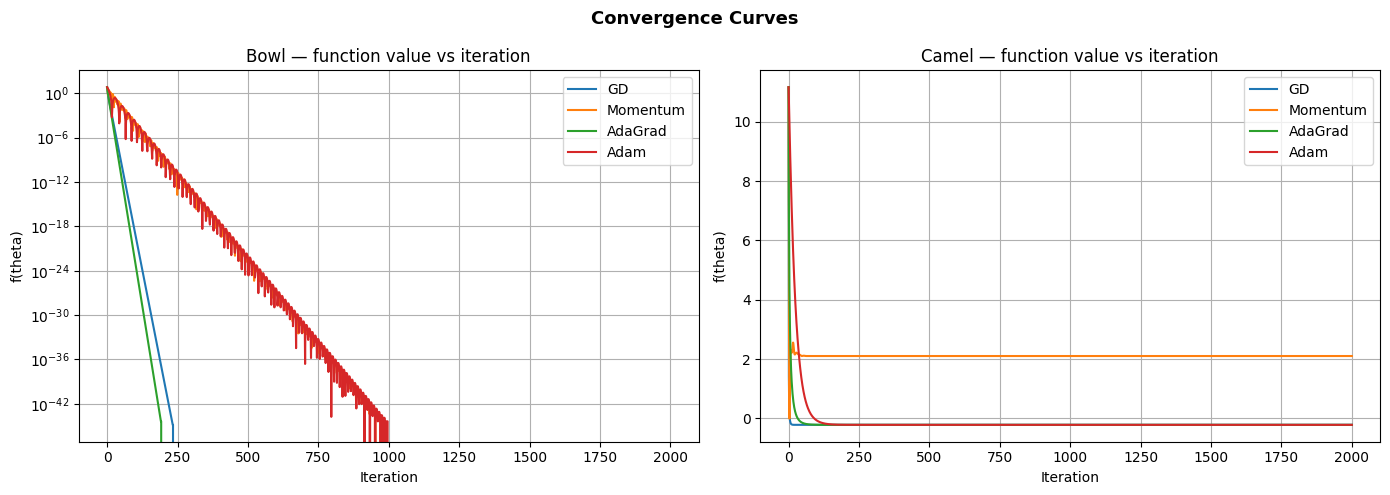

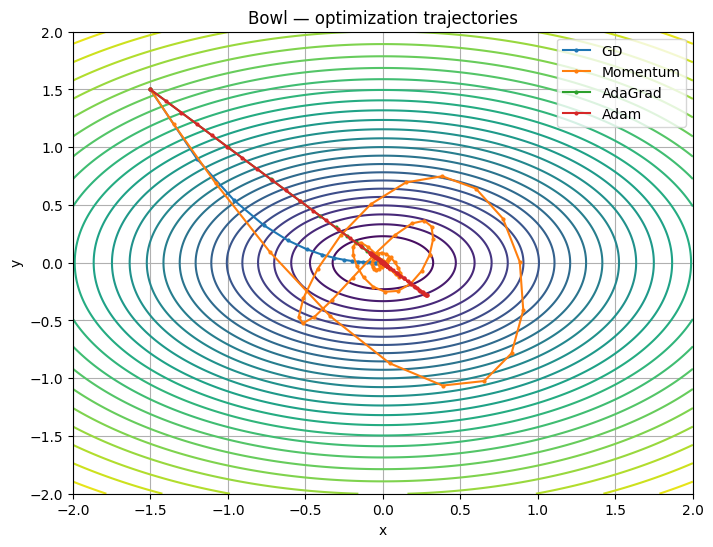

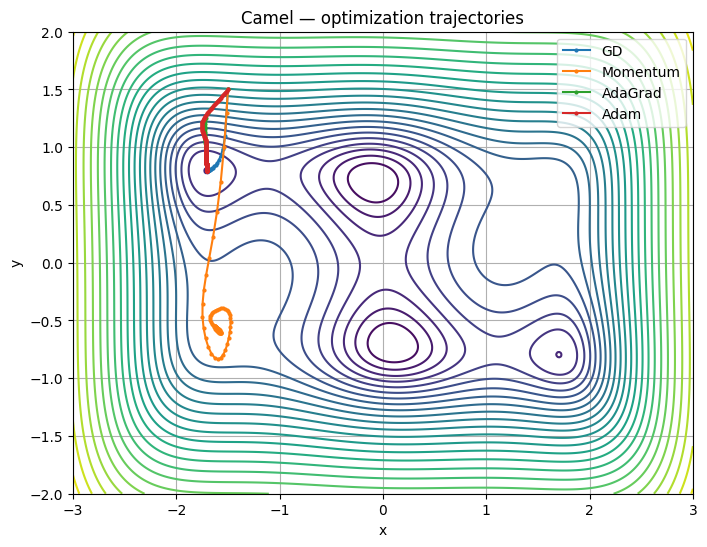

In [63]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ── Optimizers ────────────────────────────────────────────────────────────────

def gradient_descent(f, theta0, lr=0.01, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    trajectory = [theta.detach().clone()]
    values     = [f(theta).item()]
    for _ in range(n_steps):
        loss = f(theta)
        loss.backward()
        with torch.no_grad():
            theta -= lr * theta.grad
        theta.grad.zero_()
        trajectory.append(theta.detach().clone())
        values.append(f(theta).item())
    return torch.stack(trajectory), values

def momentum(f, theta0, lr=0.01, beta=0.9, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    v = torch.zeros_like(theta)
    trajectory = [theta.detach().clone()]
    values     = [f(theta).item()]
    for _ in range(n_steps):
        loss = f(theta)
        loss.backward()
        with torch.no_grad():
            v     = beta * v + theta.grad
            theta -= lr * v
        theta.grad.zero_()
        trajectory.append(theta.detach().clone())
        values.append(f(theta).item())
    return torch.stack(trajectory), values

def adagrad(f, theta0, lr=0.5, eps=1e-8, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    G = torch.zeros_like(theta)
    trajectory = [theta.detach().clone()]
    values     = [f(theta).item()]
    for _ in range(n_steps):
        loss = f(theta)
        loss.backward()
        with torch.no_grad():
            G     = G + theta.grad ** 2
            theta -= lr * theta.grad / (G.sqrt() + eps)
        theta.grad.zero_()
        trajectory.append(theta.detach().clone())
        values.append(f(theta).item())
    return torch.stack(trajectory), values

def adam(f, theta0, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    m = torch.zeros_like(theta)
    v = torch.zeros_like(theta)
    trajectory = [theta.detach().clone()]
    values     = [f(theta).item()]
    for step in range(1, n_steps + 1):
        loss = f(theta)
        loss.backward()
        with torch.no_grad():
            m     = beta1 * m + (1 - beta1) * theta.grad
            v     = beta2 * v + (1 - beta2) * theta.grad ** 2
            m_hat = m / (1 - beta1 ** step)
            v_hat = v / (1 - beta2 ** step)
            theta -= lr * m_hat / (v_hat.sqrt() + eps)
        theta.grad.zero_()
        trajectory.append(theta.detach().clone())
        values.append(f(theta).item())
    return torch.stack(trajectory), values

# ── Run experiments ───────────────────────────────────────────────────────────

theta0 = torch.tensor([-1.5, 1.5])

results_bowl = {
    "GD":       gradient_descent(bowl, theta0, lr=0.1),
    "Momentum": momentum(bowl,  theta0, lr=0.05, beta=0.9),
    "AdaGrad":  adagrad(bowl,   theta0, lr=0.5),
    "Adam":     adam(bowl,      theta0, lr=0.1),
}

results_camel = {
    "GD":       gradient_descent(camel, theta0, lr=0.01),
    "Momentum": momentum(camel,  theta0, lr=0.005, beta=0.9),
    "AdaGrad":  adagrad(camel,   theta0, lr=0.1),
    "Adam":     adam(camel,      theta0, lr=0.01),
}

# ── Visualisation 1: function value vs iteration ──────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, (_, vals) in results_bowl.items():
    ax1.plot(vals, label=name)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("f(theta)")
ax1.set_title("Bowl — function value vs iteration")
ax1.set_yscale("log")
ax1.legend()
ax1.grid(True)

for name, (_, vals) in results_camel.items():
    ax2.plot(vals, label=name)
ax2.set_xlabel("Iteration")
ax2.set_ylabel("f(theta)")
ax2.set_title("Camel — function value vs iteration")
ax2.legend()
ax2.grid(True)

plt.suptitle("Convergence Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Visualisation 2: trajectories ─────────────────────────────────────────────

plot_trajectories_camel_log(
    bowl, results_bowl,
    xlim=(-2, 2), ylim=(-2, 2),
    title="Bowl — optimization trajectories"
)

plot_trajectories_camel_log(
    camel, results_camel,
    xlim=(-3, 3), ylim=(-2, 2),
    title="Camel — optimization trajectories"
)


### Analysis — Part 2

**Convex bowl:** All four optimizers converge to the global minimum (0, 0), but at very different speeds. Adam and AdaGrad converge fastest thanks to adaptive learning rates that rescale each dimension independently — particularly useful here since the bowl is elongated (curvatures 2 and 4 differ). Plain GD takes many more steps and its path is straight but slow. Momentum accelerates GD along the dominant gradient direction but can overshoot, producing slight oscillations before settling.

**Camel (non-convex):** No optimizer reliably finds the global minimum from a fixed starting point — all can get trapped in local minima depending on initialisation. Adam tends to escape shallow local minima more readily due to its adaptive step sizes and momentum, but this is not guaranteed. GD and Momentum are more sensitive to the starting point. The optimisation paths are visibly more erratic on the camel surface because the gradient changes direction frequently.

**Hyperparameter transfer:** The same hyperparameters do not work equally well for both functions. A learning rate safe for the camel (smaller, to handle steep regions) is overly conservative for the bowl, and vice versa. AdaGrad's accumulation of squared gradients can make it slow on the camel because the accumulated sum grows too large, effectively freezing updates. Adam handles both functions well across a wider range of learning rates, making it the most robust choice in practice.

### **Knowledge Bonus.** An attempt at explaining the L1 regularization phenomenon + a bit about proximal descent



The antigradient of the regularized loss $\mathcal{L}_{reg}(w) = \mathcal{L}(w) + \lambda\|w\|_1$ is
$$-\nabla_w\mathcal{L}_{reg}(w) = -\nabla_w\mathcal{L}(w) - \lambda\cdot \mathrm{sign}(w),$$
where $\mathrm{sgn}$ is the elementwise sign. This means that during the gradient descent the $i$-th coordinate of $w$ changes as
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) + \begin{cases}
-\alpha\lambda,\mbox{ if $w_i > 0$},\\
+\alpha\lambda,\mbox{ if $w_i < 0$},
\end{cases},$$
where $\alpha$ is the step size. In other words, the rightmost summand pushes our $w_i$ towards $0$ with force $\alpha\lambda$. Now, imagine that the $i$-th feature is not very important. In this case, most likely, $\frac{\partial}{\partial w_i}\mathcal{L}(w)$ is small (change in $w_i$ doesn't change the loss much). So, the dominant force is the $\pm\alpha\lambda$, which may explain the almost-linear trajectories.

Of course, since $\alpha\lambda$ is constant and doesn't depend on $w_i$. This prevents us from converging to zero and explains the final noisy behaviour of $w_i$. We just leap around the origin.

I'd like to add here that if we used proximal descent, the step would become a two-step procedure like this:

$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w),\\
w_i\mapsto\begin{cases}
w_i - \alpha\lambda,\mbox{ if $w_i \geqslant \alpha\lambda$},\\
0,\mbox{ if $|w_i| > \alpha\lambda$},\\
w_i + \alpha\lambda,\mbox{ if $w_i \leqslant -\alpha\lambda$},\\
\end{cases}$$
This way, small values of $w_i$ will be automatically zeroed, and they will only be able to escape zero again if the gradient push them hard enough.

**Comparison with L2 regularization**. For L2 regularization, the gradient step for the $i$-th coordinate would be
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) - 2\alpha\lambda w_i$$
The rightmost term here depends on $w_i$; the closer it is to zero, the less influential it is, and the more important $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)$ becomes. However, if the $i$-th feature is so worthless that $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)\approx 0$, the process
$$w_i \mapsto w_i -  2\alpha\lambda w_i$$
converges to zero in contrast with the leaping behaviour of
$$w_i\mapsto w_i \pm\alpha\lambda$$